# Correlation

Make a correlation map of all the symbols in a portfolio

In [1]:
import datetime

import matplotlib.pyplot as plt
import pandas as pd

import pinkfish as pf

# Format price data.
pd.options.display.float_format = '{:0.2f}'.format

%matplotlib inline

In [2]:
# Set size of inline plots.
'''note: rcParams can't be in same cell as import matplotlib
   or %matplotlib inline
   
   %matplotlib notebook: will lead to interactive plots embedded within
   the notebook, you can zoom and resize the figure
   
   %matplotlib inline: only draw static images in the notebook
'''
plt.rcParams["figure.figsize"] = (10, 7)

In [3]:
symbols = ['SPY', 'GLD', 'BOND', 'EEM', 'IYR', 
           'JNK', 'LQD', 'NLY',  'PFF', 'PGX',
           'SLY', 'TIP', 'TLT',  'BSV', 'VNQ']
#symbols = ['GLD', 'GDX']
#symbols = ['SPY', '^GSPC']
#symbols = ['LQD', 'TLT']

start = datetime.datetime(2018, 1, 1)
end = datetime.datetime.now()

In [4]:
# Fetch timeseries
portfolio = pf.Portfolio()
ts = portfolio.fetch_timeseries(symbols, start, end, fields=['close'])

In [5]:
ts, start = portfolio.finalize_timeseries(ts, start)

,LQD,IYR,PFF,SLY,JNK,NLY,GLD,PGX,BOND,VNQ,BSV,SPY,EEM,TIP,TLT
LQD,1.00,0.51,0.51,0.42,0.71,0.46,0.52,0.48,0.89,0.51,0.79,0.48,0.36,0.80,0.85
IYR,0.51,1.00,0.61,0.79,0.73,0.71,0.27,0.51,0.42,1.00,0.31,0.81,0.58,0.37,0.23
PFF,0.51,0.61,1.00,0.74,0.72,0.55,0.16,0.97,0.42,0.61,0.19,0.69,0.51,0.32,0.30
SLY,0.42,0.79,0.74,1.00,0.77,0.63,0.16,0.63,0.30,0.80,0.14,0.89,0.67,0.27,0.11
JNK,0.71,0.73,0.72,0.77,1.00,0.63,0.39,0.65,0.57,0.73,0.47,0.82,0.65,0.52,0.40
NLY,0.46,0.71,0.55,0.63,0.63,1.00,0.25,0.48,0.41,0.70,0.30,0.64,0.49,0.42,0.27
GLD,0.52,0.27,0.16,0.16,0.39,0.25,1.00,0.13,0.56,0.26,0.61,0.26,0.44,0.57,0.41
PGX,0.48,0.51,0.97,0.63,0.65,0.48,0.13,1.00,0.40,0.51,0.17,0.58,0.44,0.29,0.31
BOND,0.89,0.42,0.42,0.30,0.57,0.41,0.56,0.40,1.00,0.41,0.85,0.35,0.28,0.82,0.84
VNQ,0.51,1.00,0.61,0.80,0.73,0.70,0.26,0.51,0.41,1.00,0.31,0.81,0.58,0.37,0.23


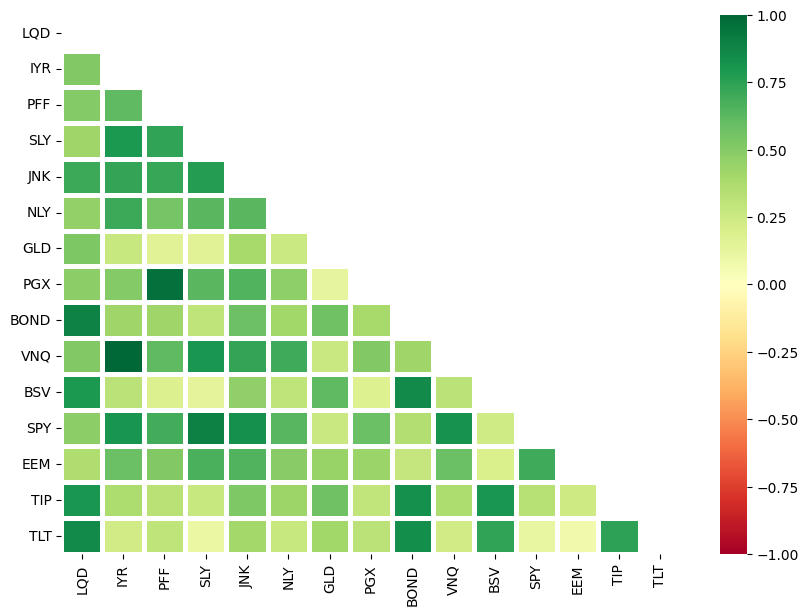

In [6]:
TRADING_DAYS_PER_YEAR, _, _ = pf.get_trading_days()
corr_df = portfolio.correlation_map(ts, method='log', days=TRADING_DAYS_PER_YEAR)
corr_df